**TGA Analysis**

In [112]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get current working directory
current_dir = Path.cwd()

# Go 2 folders up
base_dir = current_dir.parent.parent.parent

# Build the target path
target_dir = base_dir / "Measurements" / "CNT Dispersions" / "TGA"

P2_A = next(target_dir.glob("20260407_P2_RawMaterial/RefP2_test.csv"))
P2_B = next(target_dir.glob("20260407_P2_RawMaterial/RefP2_R1.csv"))
P2_C = next(target_dir.glob("20260407_P2_RawMaterial/RefP2_R2.csv"))

P2_D = next(target_dir.glob("20260408_6FBz@P2/f005ap_hexafluorobenzene@p2_swcnt_R1.csv"))
P2_E = next(target_dir.glob("20260408_6FBz@P2/f005ap_hexafluorobenzene@p2_swcnt_R2.csv"))
P2_F = next(target_dir.glob("20260408_6FBz@P2/Ref_P2_Hexafluorobenzene_wetting.csv"))


In [113]:
dfA = pd.read_csv(P2_A)
dfB = pd.read_csv(P2_B)
dfC = pd.read_csv(P2_C)
dfD = pd.read_csv(P2_D)
dfE = pd.read_csv(P2_E)
dfF = pd.read_csv(P2_F)


#Required fix for dfA since I started with the wrong ininial mass
df_A_fixed = dfA.copy()

# Step 1: flip sign
mass = -df_A_fixed["Unsubtracted Weight"]

# Step 2: convert to decreasing mass (like normal TGA)
mass = mass.iloc[0] - (mass - mass.iloc[0])

# Replace column
df_A_fixed["Unsubtracted Weight"] = mass

DFs = [#df_A_fixed, 
       #dfB,
         dfC,
           dfD,
             dfE,
               dfF]

DF_labels = [
    #"P2 (Test)",
    #"P2 (R1)",
    "ArcDisc SWCNTs",
    "6FBz@ArcSWCNTs (R1)",
    "6FBz@ArcSWCNTs (R2)",
    "6FBz + ArcSWCNTs (wetting)"
]


In [114]:
#CUSTOMIZATION

poster_style = {
    "figsize": (4, 4),          # poster-friendly
    "dpi": 250,                 # high resolution
    "font_size": 12,
    "title_size": 14,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    
    # Optional: define your own colors
    "colors": None  # e.g. ["red", "blue", "green"]
}

In [115]:
def process_tga(df,  label=None):
    df = df.dropna(subset=["Sample Temperature", "Unsubtracted Weight"])
    
    temp = df["Sample Temperature"]
    mass = df["Unsubtracted Weight"]
    
    # Find maximum temperature (robust to fluctuations)
    max_idx = temp.idxmax()
    
    # Keep only heating portion
    df_heating = df.loc[:max_idx].copy()
    
    temp_f = df_heating["Sample Temperature"]
    mass_f = df_heating["Unsubtracted Weight"].abs()
    
#    temp_f = temp
 #   mass_f = mass
    
    # Better estimate of initial mass
    m0 = mass_f.head(10).mean()
    
    # Mass remaining percentage (starts at ~100%)
    mass_pct = mass_f / m0 * 100
    
    label_value = label if label is not None else "Unknown"

    return pd.DataFrame({
        "Temperature": temp_f,
        "Mass (%)": mass_pct,
        "Label": label_value
    })



In [116]:
def plot_tga(data, style=poster_style):
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style["colors"]
    
    if not isinstance(data, list):
        label = data["Label"].iloc[0]
        plt.plot(
            data["Temperature"],
            data["Mass (%)"],
            label=label,
            linewidth=style["line_width"],
            color=colors[0] if colors else None
        )
    
    else:
        for i, df in enumerate(data):
            label = df["Label"].iloc[0]
            plt.plot(
                df["Temperature"],
                df["Mass (%)"],
                label=label,
                linewidth=style["line_width"],
                color=colors[i] if colors else None
            )
    
    plt.xlabel("Temperature (°C)", fontsize=style["label_size"])
    plt.ylabel("Mass (%)", fontsize=style["label_size"])
    plt.title("TGA Curve", fontsize=style["title_size"])
    
    plt.ylim(70, 101)
    plt.xlim(50, 790)
    
    plt.legend(fontsize=style["legend_size"])
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [117]:
def compute_dtg(df, step=1.0, smooth_window=20):
    df = df.copy()
    
    # --- 1. Clean data ---
    df = df.dropna(subset=["Temperature", "Mass (%)"])
    df = df.sort_values("Temperature")
    df = df.drop_duplicates(subset="Temperature")
    
    # Remove non-increasing temperature steps (important!)
    df = df[df["Temperature"].diff().fillna(1) > 0]
    
    # --- 2. Resample to uniform temperature grid ---
    t_min, t_max = df["Temperature"].min(), df["Temperature"].max()
    temp_uniform = np.arange(t_min, t_max, step)
    
    mass_uniform = np.interp(temp_uniform, df["Temperature"], df["Mass (%)"])
    
    # --- 3. Light smoothing (like datasmooth in MATLAB) ---
    if smooth_window > 1:
        mass_uniform = (
            pd.Series(mass_uniform)
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
            .values
        )
    
    # --- 4. Compute derivative ---
    dmdt = np.gradient(mass_uniform, temp_uniform)
    
    # --- 5. Optional second smoothing (DTG cleanup) ---
    if smooth_window > 1:
        dmdt = (
            pd.Series(dmdt)
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
            .values
        )
    
    # --- 6. Flip sign (DTG convention) ---
    dmdt = -dmdt
    
    label_value = df["Label"].iloc[0] if "Label" in df.columns else "Unknown"
    
    return pd.DataFrame({
        "Temperature": temp_uniform,
        "DTG (%/°C)": dmdt,
        "Label": label_value
    })





In [120]:
def plot_dtg(data, style=poster_style):
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style["colors"]
    
    if not isinstance(data, list):
        df = data
        label = df["Label"].iloc[0]
        
        plt.plot(
            df["Temperature"],
            df["DTG (%/°C)"],
            label=label,
            linewidth=style["line_width"],
            color=colors[0] if colors else None
        )
    
    else:
        for i, df in enumerate(data):
            label = df["Label"].iloc[0]
            
            plt.plot(
                df["Temperature"],
                df["DTG (%/°C)"],
                label=label,
                linewidth=style["line_width"],
                color=colors[i] if colors else None
            )
    
    plt.xlabel("Temperature (°C)", fontsize=style["label_size"])
    plt.ylabel("DTG (%/°C)", fontsize=style["label_size"])
    plt.title("DTG Curve", fontsize=style["title_size"])
    
    plt.xlim(30, 1100)
#    plt.xlim(50, 790)

    plt.ylim(-0.01, 0.125)
    
    plt.legend(fontsize=style["legend_size"])
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

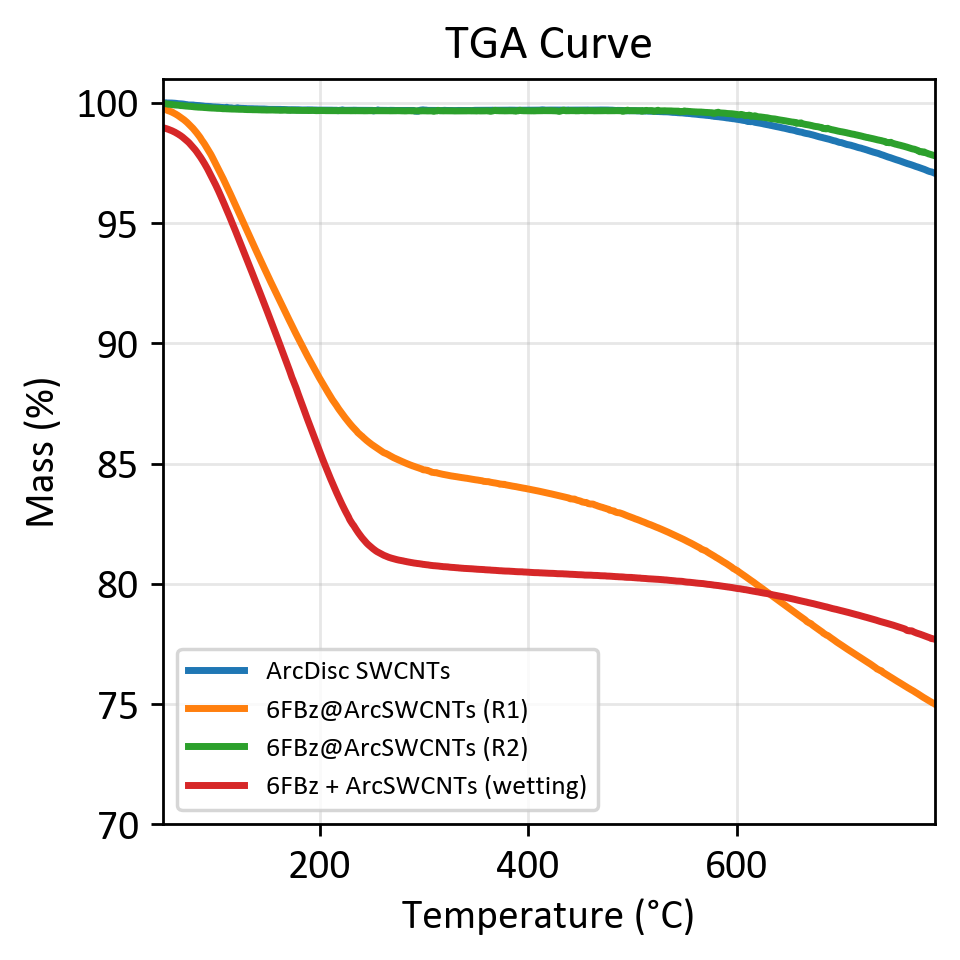

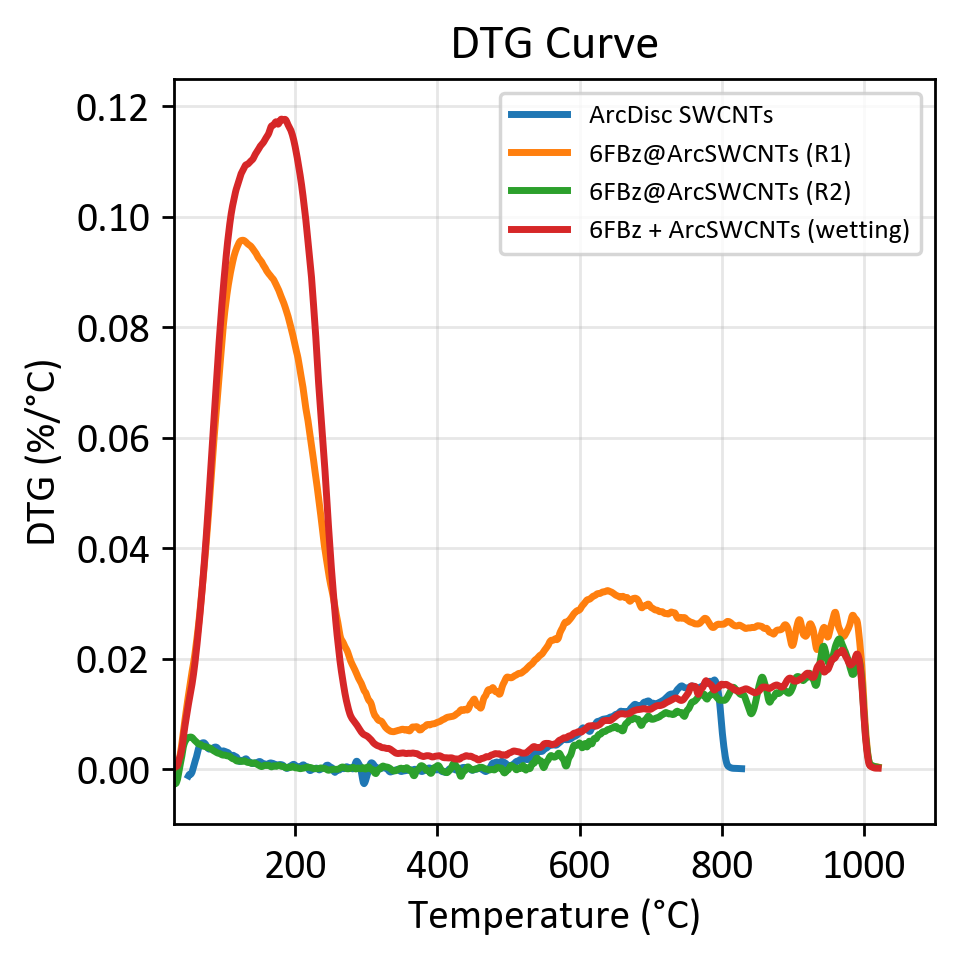

In [121]:
DFs = [#df_A_fixed, 
       #dfB,
         dfC,
           dfD,
             dfE,
               dfF
             ]

DF_labels = [
    #"P2 (Test)",
    #"P2 (R1)",
    "ArcDisc SWCNTs",

    "6FBz@ArcSWCNTs (R1)",
    "6FBz@ArcSWCNTs (R2)",
    "6FBz + ArcSWCNTs (wetting)"
]

TGA_DFs = [process_tga(df, label) for df, label in zip(DFs, DF_labels)]
plot_tga(TGA_DFs)

DTGA_DFs = [compute_dtg(df, smooth_window=10) for df in TGA_DFs]
plot_dtg(DTGA_DFs)